# Tarea 2.3

### Introducción
En esta actividad, implementaremos un sistema de clasificación para detectar anomalías en datos de salud (BPM, HRV y SpO2). Compararemos el rendimiento de un modelo KNN utilizando el conjunto de datos completo frente a uno simplificado mediante PCA, analizando cómo la reducción de dimensiones impacta en la precisión y eficiencia del diagnóstico.

## Importación de Librerías
Aqui cargamos las herramientas necesarias para la manipulación de datos (pandas), el modelado de IA (sklearn) y la visualización de los resultados (matplotlib).

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


## Carga de Datos
Aqui se lee el archivo csv con los datos recibidos del esp32 (Media de la Frecuencia Cardíaca, RMSSD (Métrica de HRV) y Estabilidad del $SpO_2$) de dos semanas (aproximadamente 4000 registros)

nota: aproximadame el 5% de los datos estan contaminados a proposito para saber como se comportan los modelos en esta situación

In [27]:
df = pd.read_csv('datos_salud.csv')
print("Archivo cargado con éxito.")
print(f"Total de registros (ventanas de 5 min): {df.shape[0]}")
print(df.head())

Archivo cargado con éxito.
Total de registros (ventanas de 5 min): 4032
                    timestamp  media_bpm   rmssd_hrv  std_spo2  \
0  2026-06-18 21:25:01.344954  74.235214   37.308678  0.597153   
1  2026-06-18 21:30:01.344954  78.853634   36.829233  0.464879   
2  2026-06-18 21:35:01.344954  69.214440  108.777172  0.469925   
3  2026-06-18 21:40:01.344954  74.441520   35.682912  0.430141   
4  2026-06-18 21:45:01.344954  73.088830   28.433599  0.241262   

   es_anomalio_real  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


## Preprocesamiento de Datos
Antes de entrenar los modelos, es necesario normalizar las características para que todas tengan la misma escala y dividir los datos en conjuntos de entrenamiento y prueba.

In [28]:
X = df[['media_bpm', 'rmssd_hrv', 'std_spo2']]
y = df['es_anomalio_real']

# Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

## Modelo 1: Clasificación con Dataset Original
En esta sección entrenamos un modelo K-Nearest Neighbors (KNN) utilizando todas las características originales escaladas.

In [29]:
modelo_orig = KNeighborsClassifier(n_neighbors=5)
modelo_orig.fit(X_train, y_train)
y_pred_orig = modelo_orig.predict(X_test)

print("Reporte de Clasificación - Dataset Original:")
print(classification_report(y_test, y_pred_orig))

Reporte de Clasificación - Dataset Original:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1163
           1       1.00      1.00      1.00        47

    accuracy                           1.00      1210
   macro avg       1.00      1.00      1.00      1210
weighted avg       1.00      1.00      1.00      1210



## Modelo 2: Clasificación con Reducción de Dimensionalidad (PCA)
Aplicamos PCA para reducir las 3 dimensiones originales a 2, y luego entrenamos un modelo idéntico al anterior.

In [30]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

modelo_pca = KNeighborsClassifier(n_neighbors=5)
modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)

print("Reporte de Clasificación - Con PCA (2 Componentes):")
print(classification_report(y_test, y_pred_pca))

Reporte de Clasificación - Con PCA (2 Componentes):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1163
           1       1.00      1.00      1.00        47

    accuracy                           1.00      1210
   macro avg       1.00      1.00      1.00      1210
weighted avg       1.00      1.00      1.00      1210



## Comparativa de Resultados
Analizamos el rendimiento de ambos modelos para observar si la reducción de dimensionalidad afecta la precisión en la detección de anomalías.

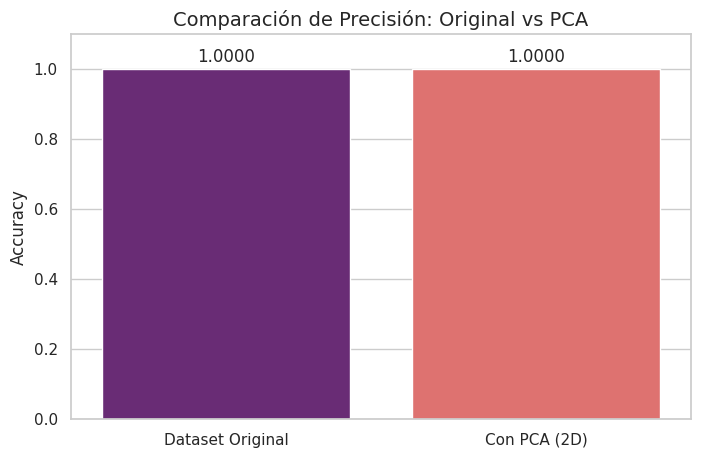

In [31]:
acc_orig = accuracy_score(y_test, y_pred_orig)
acc_pca = accuracy_score(y_test, y_pred_pca)

# Configuración de estilo
sns.set_theme(style="whitegrid")
modelos = ['Dataset Original', 'Con PCA (2D)']
precisiones = [acc_orig, acc_pca]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=modelos, y=precisiones, hue=modelos, palette='magma', legend=False)

plt.title('Comparación de Precisión: Original vs PCA', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)

# Añadir etiquetas de valor
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

### Conclusión
Los resultados demuestran que ambos modelos alcanzaron una precisión del 100%, indicando que las anomalías son altamente distinguibles. La reducción de dimensiones con PCA mantuvo la eficacia del modelo, permitiendo procesar menos datos sin pérdida de información, lo cual es ideal para dispositivos con recursos limitados como el ESP32.